<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
Y = data.target

X_treino, X_teste, Y_treino, Y_teste = train_test_split(
X,
Y,
test_size = 0.2,
random_state = 42,
stratify = Y,
)

print(f'Treino: {X_treino.shape}')
print(f'Teste: {X_teste.shape}')

Treino: (120, 4)
Teste: (30, 4)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(
    #teste de max_depth apontou que 3 é o sweetspot
    max_depth=3,
    random_state=42
)

model.fit(X_treino, Y_treino)

y_pred_teste = model.predict(X_teste)
y_pred_treino = model.predict(X_treino)

acuracia_teste = accuracy_score(Y_teste, y_pred_teste)
acuracia_treino = accuracy_score(Y_treino, y_pred_treino)
print(f"Acuracia no teste: {acuracia_teste}")
print(f"Acuracia no treino: {acuracia_treino}")

Acuracia no teste: 0.9666666666666667
Acuracia no treino: 0.9833333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

Atributo na raiz: 2
Profundidade: 3


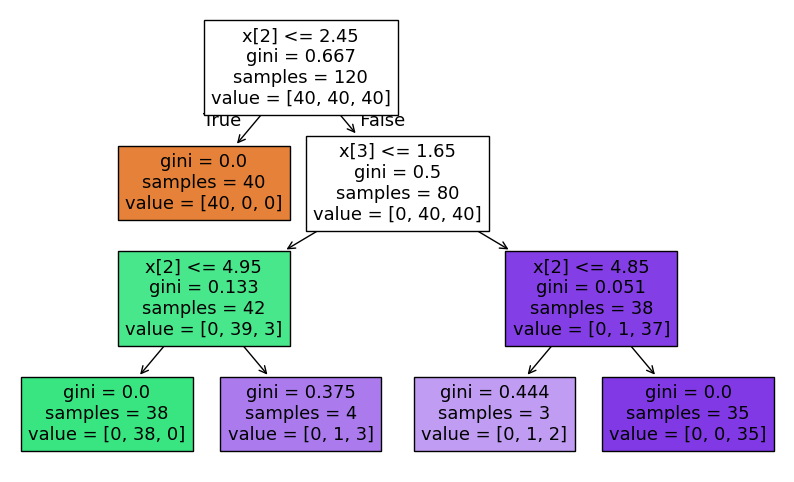

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plot_tree(model,filled=True)

plt.show

print(f'Atributo na raiz: {model.tree_.feature[0]}')
print(f'Profundidade: {model.max_depth}')

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [24]:
for i in range(1, 9):
    model = DecisionTreeClassifier(
    #teste de max_depth apontou que 3 é o sweetspot
    max_depth=i,
    random_state=42
    )

    model.fit(X_treino, Y_treino)

    y_pred_teste = model.predict(X_teste)
    y_pred_treino = model.predict(X_treino)

    acuracia_teste = accuracy_score(Y_teste, y_pred_teste)
    acuracia_treino = accuracy_score(Y_treino, y_pred_treino)
    print(f"Acuracia no teste [{i}]: {acuracia_teste}")
    print(f"Acuracia no treino [{i}]: {acuracia_treino}")
    print(f'Profundidade: {model.max_depth}')
    print(f'Número de folhas: {model.get_n_leaves()}')


model = DecisionTreeClassifier(
#teste de max_depth apontou que 3 é o sweetspot
max_depth= None,
random_state=42
)

model.fit(X_treino, Y_treino)

y_pred_teste = model.predict(X_teste)
y_pred_treino = model.predict(X_treino)

acuracia_teste = accuracy_score(Y_teste, y_pred_teste)
acuracia_treino = accuracy_score(Y_treino, y_pred_treino)
print(f"Acuracia no teste [None]: {acuracia_teste}")
print(f"Acuracia no treino [None]: {acuracia_treino}")
print(f'Profundidade: {model.max_depth}')
print(f'Número de folhas: {model.get_n_leaves()}')



Acuracia no teste [1]: 0.6666666666666666
Acuracia no treino [1]: 0.6666666666666666
Profundidade: 1
Número de folhas: 2
Acuracia no teste [2]: 0.9333333333333333
Acuracia no treino [2]: 0.9666666666666667
Profundidade: 2
Número de folhas: 3
Acuracia no teste [3]: 0.9666666666666667
Acuracia no treino [3]: 0.9833333333333333
Profundidade: 3
Número de folhas: 5
Acuracia no teste [4]: 0.9333333333333333
Acuracia no treino [4]: 0.9916666666666667
Profundidade: 4
Número de folhas: 7
Acuracia no teste [5]: 0.9333333333333333
Acuracia no treino [5]: 1.0
Profundidade: 5
Número de folhas: 8
Acuracia no teste [6]: 0.9333333333333333
Acuracia no treino [6]: 1.0
Profundidade: 6
Número de folhas: 8
Acuracia no teste [7]: 0.9333333333333333
Acuracia no treino [7]: 1.0
Profundidade: 7
Número de folhas: 8
Acuracia no teste [8]: 0.9333333333333333
Acuracia no treino [8]: 1.0
Profundidade: 8
Número de folhas: 8
Acuracia no teste [None]: 0.9333333333333333
Acuracia no treino [None]: 1.0
Profundidade: No

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

R1: Profundidade 5.
R2: Porque o máximo de profundidade de overfiting é 5. O threshold já foi atingido muito antes do None.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [26]:
model_gini = DecisionTreeClassifier(
    max_depth=3,
    criterion="gini",
    random_state=42
)

model_entropy = DecisionTreeClassifier(
    max_depth=3,
    criterion="entropy",
    random_state=42
)

model_gini.fit(X_treino, Y_treino)
model_entropy.fit(X_treino, Y_treino)

y_pred_gini = model_gini.predict(X_teste)
y_pred_entropy = model_entropy.predict(X_teste)

acuracia_gini = accuracy_score(Y_teste, y_pred_gini)
acuracia_entropy = accuracy_score(Y_teste, y_pred_entropy)

print(f'Acurácia Gini: {acuracia_gini}')
print(f'Acurácia Entropy: {acuracia_entropy}')

print(f'Profundidade Gini: {model_gini.max_depth}')
print(f'Profundidade Entropy: {model_entropy.max_depth}')

Acurácia Gini: 0.9666666666666667
Acurácia Entropy: 0.9666666666666667
Profundidade Gini: 3
Profundidade Entropy: 3


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [ ]:
for i in range(1, 9):
    model = DecisionTreeClassifier(
    #teste de max_depth apontou que 3 é o sweetspot
    max_depth=i,
    random_state=42
    )

    model.fit(X_treino, Y_treino)

    y_pred_teste = model.predict(X_teste)
    y_pred_treino = model.predict(X_treino)

    acuracia_teste = accuracy_score(Y_teste, y_pred_teste)
    acuracia_treino = accuracy_score(Y_treino, y_pred_treino)
    print(f"Acuracia no teste [{i}]: {acuracia_teste}")
    print(f"Acuracia no treino [{i}]: {acuracia_treino}")
    print(f'Profundidade: {model.max_depth}')
    print(f'Número de folhas: {model.get_n_leaves()}')


model = DecisionTreeClassifier(
#teste de max_depth apontou que 3 é o sweetspot
max_depth= None,
random_state=42
)

model.fit(X_treino, Y_treino)

y_pred_teste = model.predict(X_teste)
y_pred_treino = model.predict(X_treino)

acuracia_teste = accuracy_score(Y_teste, y_pred_teste)
acuracia_treino = accuracy_score(Y_treino, y_pred_treino)
print(f"Acuracia no teste [None]: {acuracia_teste}")
print(f"Acuracia no treino [None]: {acuracia_treino}")
print(f'Profundidade: {model.max_depth}')
print(f'Número de folhas: {model.get_n_leaves()}')



Acuracia no teste [1]: 0.6666666666666666
Acuracia no treino [1]: 0.6666666666666666
Profundidade: 1
Número de folhas: 2
Acuracia no teste [2]: 0.9333333333333333
Acuracia no treino [2]: 0.9666666666666667
Profundidade: 2
Número de folhas: 3
Acuracia no teste [3]: 0.9666666666666667
Acuracia no treino [3]: 0.9833333333333333
Profundidade: 3
Número de folhas: 5
Acuracia no teste [4]: 0.9333333333333333
Acuracia no treino [4]: 0.9916666666666667
Profundidade: 4
Número de folhas: 7
Acuracia no teste [5]: 0.9333333333333333
Acuracia no treino [5]: 1.0
Profundidade: 5
Número de folhas: 8
Acuracia no teste [6]: 0.9333333333333333
Acuracia no treino [6]: 1.0
Profundidade: 6
Número de folhas: 8
Acuracia no teste [7]: 0.9333333333333333
Acuracia no treino [7]: 1.0
Profundidade: 7
Número de folhas: 8
Acuracia no teste [8]: 0.9333333333333333
Acuracia no treino [8]: 1.0
Profundidade: 8
Número de folhas: 8
Acuracia no teste [None]: 0.9333333333333333
Acuracia no treino [None]: 1.0
Profundidade: No

O melhor modelo foi o com max depth 3, pois a teve uma melhor acurácia no teste e evitou o overfiting na acurácia de treino.